In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    average_precision_score,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

route = '/content/default of credit card clients.xls'

data = pd.read_excel(route, skiprows= 1)

In [2]:
### Esta función es un helper para la visualización de las métricas
## Y también para el plot
## Dado el contexto lo dejare en el notebook, sin embargo,
## Puede ser un archivo helper .py

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    roc_auc_score,
    average_precision_score,
    classification_report
)


def evaluar_clasificador_sklearn(
    model,
    X,
    y_true,
    clases=[0, 1],
    positive_label=1,
    titulo="Modelo"
):
    y_pred = model.predict(X)

    # Para ROC AUC y PR AUC necesitamos probabilidades o scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    else:
        y_score = None

    print("=" * 50)
    print(titulo)
    print("=" * 50)

    for clase in clases:
        print(f"Clase {clase}")

        tp = np.sum((y_true == clase) & (y_pred == clase))
        fp = np.sum((y_true != clase) & (y_pred == clase))
        fn = np.sum((y_true == clase) & (y_pred != clase))

        soporte = np.sum(y_true == clase)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        print("Soporte:", soporte)
        print("TP:", tp)
        print("FP:", fp)
        print("FN:", fn)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1:", f1)
        print("---" * 10)

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=clases
        )
    )

    if y_score is not None:
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)

        print("ROC AUC:", roc_auc)
        print("PR AUC:", pr_auc)
    else:
        roc_auc = None
        pr_auc = None
        print("Este modelo no tiene predict_proba ni decision_function. No se puede calcular ROC AUC / PR AUC.")

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=clases
    )

    print("\nMatriz de confusión:")
    print(cm)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax1, ax2, ax3 = axes

    cm_visualizer = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=clases
    )

    cm_visualizer.plot(ax=ax1)
    ax1.set_title(f"{titulo} - Matriz de confusión")

    if y_score is not None:
        PrecisionRecallDisplay.from_estimator(
            model,
            X,
            y_true,
            ax=ax2
        )
        ax2.set_title(f"{titulo} - Precision Recall")

        RocCurveDisplay.from_estimator(
            model,
            X,
            y_true,
            ax=ax3
        )
        ax3.set_title(f"{titulo} - ROC Curve")
    else:
        ax2.text(0.5, 0.5, "No disponible", ha="center", va="center")
        ax2.set_title("Precision Recall")

        ax3.text(0.5, 0.5, "No disponible", ha="center", va="center")
        ax3.set_title("ROC Curve")

    plt.tight_layout()
    plt.show()

    return {
        "y_pred": y_pred,
        "y_score": y_score,
        "confusion_matrix": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [4]:
target = 'default payment next month'

payment_cols = [f'PAY_{i}' for i in range(0, 7)]
payment_cols.remove('PAY_1')

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE'] + payment_cols

bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]

pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

numeric_cols = bill_cols + pay_cols

In [5]:
for columna in cat_cols:
  print(f'Nombre de Columna: {columna}')
  print(data[columna].unique())

Nombre de Columna: SEX
[2 1]
Nombre de Columna: EDUCATION
[2 1 3 5 4 6 0]
Nombre de Columna: MARRIAGE
[1 2 3 0]
Nombre de Columna: PAY_0
[ 2 -1  0 -2  1  3  4  8  7  5  6]
Nombre de Columna: PAY_2
[ 2  0 -1 -2  3  5  7  4  1  6  8]
Nombre de Columna: PAY_3
[-1  0  2 -2  3  4  6  7  1  5  8]
Nombre de Columna: PAY_4
[-1  0 -2  2  3  4  5  7  6  1  8]
Nombre de Columna: PAY_5
[-2  0 -1  2  3  5  4  7  8  6]
Nombre de Columna: PAY_6
[-2  2  0 -1  3  6  4  7  8  5]


In [6]:
## Estas son columnas que de acuerdo a la documentación tienen etiquetas 'extras'
## Tambien el dato -2 que aparece en PAY_*, se revisará mas adelante.

cols_sospechosas = ['EDUCATION', 'MARRIAGE']

print('Columnas con Zeros en Education y Marriage')

for columna in cols_sospechosas:
  view_zeroes = data[data[columna] == 0]
  print(view_zeroes.shape)

Columnas con Zeros en Education y Marriage
(14, 25)
(54, 25)


## Respecto a Education y Marriage

Se han detectado categorias no documentadas como 0, para este ejercicio los registros con cero en education seran removidos, mientras que marriage, se mandara a la categoria 'others.

Code from below needs to bee updated on the preprocessor pipeline, this is a minimal data leakage

In [7]:
data['MARRIAGE_clean'] = data['MARRIAGE'].replace({
        0 : 3
})

## No realizaré el cambio de Education en este punto.

In [8]:
cols_sospechosas = payment_cols

print('Columnas con Zeros en PAY_')

for columna in cols_sospechosas:
  print(f'Columna: {columna}')
  view_zeroes = data[data[columna] == -2]
  print(view_zeroes.shape)

Columnas con Zeros en PAY_
Columna: PAY_0
(2759, 26)
Columna: PAY_2
(3782, 26)
Columna: PAY_3
(4085, 26)
Columna: PAY_4
(4348, 26)
Columna: PAY_5
(4546, 26)
Columna: PAY_6
(4895, 26)


## Respecto a PAY_*

La categoría -2 no esta listada dentro de la documentación, sin embargo, al ser un conjunto de tamaño considerable, optaré por mantenerlo.

In [9]:
data['AGE'].unique()

array([24, 26, 34, 37, 57, 29, 23, 28, 35, 51, 41, 30, 49, 39, 40, 27, 47,
       33, 32, 54, 58, 22, 25, 31, 46, 42, 43, 45, 56, 44, 53, 38, 63, 36,
       52, 48, 55, 60, 50, 75, 61, 73, 59, 21, 67, 66, 62, 70, 72, 64, 65,
       71, 69, 68, 79, 74])

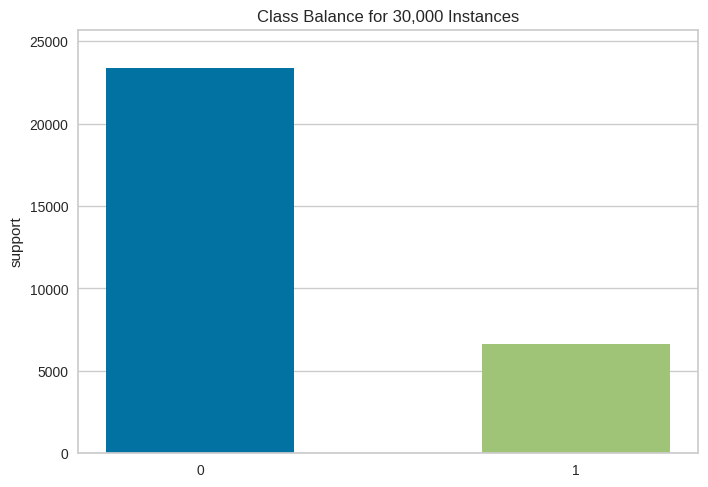

<Axes: title={'center': 'Class Balance for 30,000 Instances'}, ylabel='support'>

In [10]:
from yellowbrick.target import ClassBalance

data_copy = data.copy()

X = data_copy
y = X.pop(target)

visualizer = ClassBalance(
    labels = ['0', '1']
)

visualizer.fit(y)
visualizer.show()

In [11]:
clase_1 = data[target].sum()
clase_0 = len(data[target]) - clase_1

print(f'Tamaño de la clase 0 ', clase_0)
print(f'Tamaño de la clase 1 ', clase_1)

Tamaño de la clase 0  23364
Tamaño de la clase 1  6636


Data 0, columna: BILL_AMT1
Valor mínimo -165580, Valor máximo 964511
Data 1, columna: BILL_AMT2
Valor mínimo -69777, Valor máximo 983931
Data 2, columna: BILL_AMT3
Valor mínimo -157264, Valor máximo 1664089
Data 3, columna: BILL_AMT4
Valor mínimo -170000, Valor máximo 891586
Data 4, columna: BILL_AMT5
Valor mínimo -81334, Valor máximo 927171
Data 5, columna: BILL_AMT6
Valor mínimo -339603, Valor máximo 961664


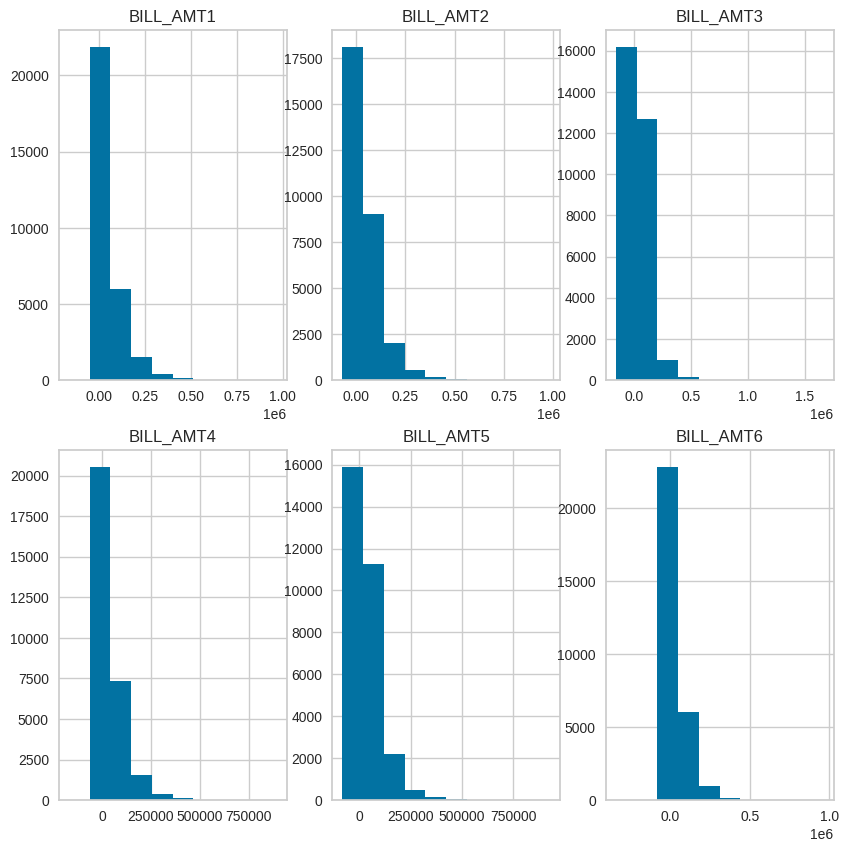

In [12]:
from math import ceil

def revisar_log(df, columnas):
  resumen = []

  for col in columnas:
      total = len(df)
      zeros = (df[col] == 0).sum()
      negatives = (df[col] < 0).sum()
      positives = (df[col] > 0).sum()
      missing = df[col].isna().sum()

      resumen.append({
          "columna": col,
          "total": total,
          "zeros": zeros,
          "zeros_pct": zeros / total,
          "negatives": negatives,
          "negatives_pct": negatives / total,
          "positives": positives,
          "missing": missing,
          "puede_log": negatives == 0 and zeros == 0,
          "puede_log1p": negatives == 0
      })

  return pd.DataFrame(resumen)


plot_cols = 3
plot_rows = ceil(len(bill_cols) / plot_cols)

fig, axes = plt.subplots(plot_rows, plot_cols, figsize = (10, 10))

axes = axes.flatten()

for i, col in enumerate(bill_cols):
  print(f'Data {i}, columna: {col}')
  min = data[col].min()
  max = data[col].max()
  print(f'Valor mínimo {min}, Valor máximo {max}')
  axes[i].hist(data[col])
  axes[i].set_title(col)

plt.show()

## Nota

Como es esperado en variables monetarias existen outliers considerables de acuerdo a los histogramas. No usar np1log dada la existencia de ceros.

In [13]:
resumen_log = revisar_log(data, bill_cols)
resumen_log

,columna,total,zeros,zeros_pct,negatives,negatives_pct,positives,missing,puede_log,puede_log1p
0,BILL_AMT1,30000,2008,0.066933,590,0.019667,27402,0,False,False
1,BILL_AMT2,30000,2506,0.083533,669,0.022300,26825,0,False,False
2,BILL_AMT3,30000,2870,0.095667,655,0.021833,26475,0,False,False
3,BILL_AMT4,30000,3195,0.106500,675,0.022500,26130,0,False,False
4,BILL_AMT5,30000,3506,0.116867,655,0.021833,25839,0,False,False
5,BILL_AMT6,30000,4020,0.134000,688,0.022933,25292,0,False,False


Data 0, columna: PAY_AMT1
Data 1, columna: PAY_AMT2
Data 2, columna: PAY_AMT3
Data 3, columna: PAY_AMT4
Data 4, columna: PAY_AMT5
Data 5, columna: PAY_AMT6


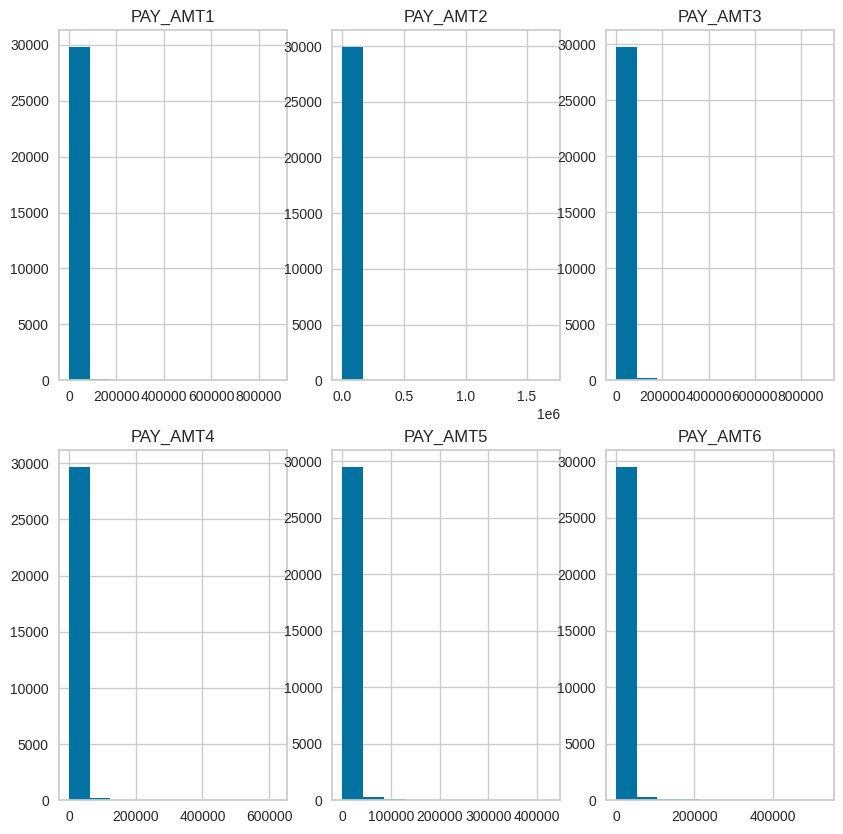

In [14]:
plot_cols = 3
plot_rows = ceil(len(pay_cols) / plot_cols)

fig, axes = plt.subplots(plot_rows, plot_cols, figsize = (10, 10))

axes = axes.flatten()

for i, col in enumerate(pay_cols):
  print(f'Data {i}, columna: {col}')
  axes[i].hist(data[col])
  axes[i].set_title(col)

plt.show()

In [15]:
resumen_log_payment = revisar_log(data, pay_cols)
resumen_log_payment

,columna,total,zeros,zeros_pct,negatives,negatives_pct,positives,missing,puede_log,puede_log1p
0,PAY_AMT1,30000,5249,0.174967,0,0.0,24751,0,False,True
1,PAY_AMT2,30000,5396,0.179867,0,0.0,24604,0,False,True
2,PAY_AMT3,30000,5968,0.198933,0,0.0,24032,0,False,True
3,PAY_AMT4,30000,6408,0.213600,0,0.0,23592,0,False,True
4,PAY_AMT5,30000,6703,0.223433,0,0.0,23297,0,False,True
5,PAY_AMT6,30000,7173,0.239100,0,0.0,22827,0,False,True


## Nota

Ocurre un fenomeno similar a BillAmount, sin embargo este es candidato a una transformación np1log durante el preprocessing pipeline.

In [16]:
## Quick check del sesgo, importante para transformaciones

skew_data = data[numeric_cols].skew().sort_values(ascending = False)
skew_data

,0
PAY_AMT2,30.453817
PAY_AMT3,17.216635
PAY_AMT1,14.668364
PAY_AMT4,12.904985
PAY_AMT5,11.127417
PAY_AMT6,10.640727
BILL_AMT3,3.087830
BILL_AMT5,2.876380
BILL_AMT6,2.846645
BILL_AMT4,2.821965


## Nota de decisión

Aquí he decidido remover los registros en cero con educación, ya que la documentación no marca la existencia de este registro y al ser 14 rows es una perdida aceptable. No obstante esta abierto a discusión dado que todas las variables relacionadas a dichos registros se ven saludables.

In [17]:
data[data['EDUCATION'] == 0]

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,MARRIAGE_clean
3769,3770,290000,2,0,2,38,1,-1,-1,-1,...,2196,1481,1437,3078,1406,2196,1481,0,0,2
5945,5946,270000,1,0,2,39,1,-1,-1,-1,...,0,0,10193,70213,19008,399,0,0,0,2
6876,6877,360000,1,0,2,30,0,0,-1,0,...,36777,30,23000,12280,25007,25008,1767,3300,0,2
14631,14632,350000,2,0,2,53,-1,-1,-1,-1,...,1385,6043,4840,61349,22687,1389,6058,1153,0,2
15107,15108,210000,1,0,2,45,-2,-2,-2,-2,...,3499,3372,5854,1032,788,3565,3372,15381,0,2
16881,16882,100000,1,0,2,37,0,0,-2,-2,...,0,0,0,0,0,0,0,0,0,2
16896,16897,200000,1,0,2,40,1,-2,-1,-1,...,0,0,0,200,1000,0,0,0,0,2
17414,17415,230000,2,0,2,47,-1,-1,-1,2,...,5425,4838,5743,1598,0,5425,4838,3840,0,2
19920,19921,50000,2,0,1,40,0,0,0,0,...,40500,41921,2229,2298,2100,2500,1921,8432,0,1
20030,20031,200000,2,0,2,30,-1,-1,2,-1,...,5816,7809,2880,0,9470,5834,7809,2886,0,2


In [18]:
## Aqui estoy removiendo los registros con education en 0
## Abierto a discusión

data_clear = (
    data[data['EDUCATION'] != 0]
    .copy()
    .drop(columns = ['ID', 'MARRIAGE']) ## MARRIAGE dado que tenemos marriage_clean
)

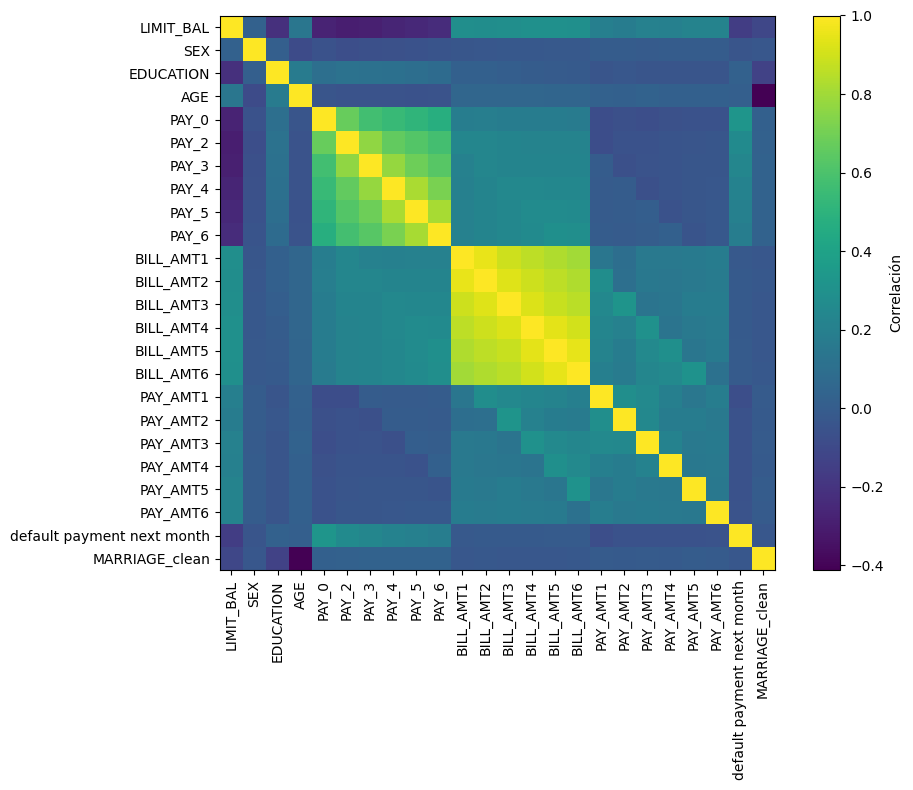

In [19]:
## Solo un check rápido de corr visual, más adelante valoro a profundidad.
plt.close('all')
plt.rcdefaults()

corr = data_clear.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap='viridis')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

fig.colorbar(im, ax=ax, label='Correlación')

plt.tight_layout()
plt.show()

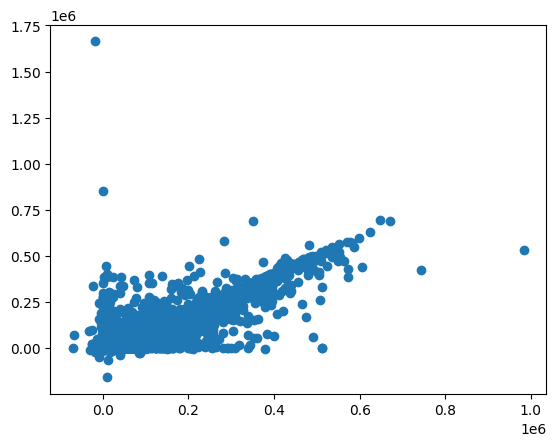

In [20]:
x = data_clear['BILL_AMT2']
y = data_clear['BILL_AMT3']

plt.scatter(
    x,y
)

## Feature Engineering (FE)

Este es uno de los bloques más importantes ya que BILL_AMT y PAY_AMT son variables que son sensibles a multicolinealidad, la cual se revisara despues del FE con un Variance Inflation Factor (VIF).

In [21]:
data_model = data_clear.copy()

data_model["BILL_AMT_mean"] = data_model[bill_cols].mean(axis=1)
data_model["BILL_AMT_max"] = data_model[bill_cols].max(axis=1)
data_model["BILL_AMT_std"] = data_model[bill_cols].std(axis=1)

data_model["PAY_AMT_mean"] = data_model[pay_cols].mean(axis=1)
data_model["PAY_AMT_max"] = data_model[pay_cols].max(axis=1)
data_model["PAY_AMT_std"] = data_model[pay_cols].std(axis=1)

data_model["debt_to_limit"] = np.where(
    data_model["LIMIT_BAL"] > 0,
    data_model["BILL_AMT_mean"] / data_model["LIMIT_BAL"],
    0
)

data_model["payment_to_debt"] = np.where(
    data_model["BILL_AMT_mean"] > 0,
    data_model["PAY_AMT_mean"] / data_model["BILL_AMT_mean"],
    0
)

data_model = data_model.drop(columns=bill_cols)
data_model = data_model.drop(columns=pay_cols)

In [22]:
data_model.skew()

,0
LIMIT_BAL,0.993327
SEX,-0.424533
EDUCATION,0.977245
AGE,0.732576
PAY_0,0.732311
PAY_2,0.790459
PAY_3,0.840632
PAY_4,0.999716
PAY_5,1.008135
PAY_6,0.947978


In [23]:
## Importante para tirar skewness de las variables
cols_to_skew= ['PAY_AMT_mean', 'PAY_AMT_max', 'PAY_AMT_std', 'BILL_AMT_mean', 'BILL_AMT_max', 'BILL_AMT_std']

view_to_skew = data_model[cols_to_skew]

skew_table = (
    view_to_skew
    .skew()
    .reset_index()
)

skew_table.columns = ['variable', 'skewness']
skew_table.sort_values('skewness', ascending = False)

final_cols_to_n1p = skew_table[skew_table['skewness'] > 9.5]['variable'].to_list()
final_cols_to_n1p

['PAY_AMT_mean', 'PAY_AMT_max', 'PAY_AMT_std']

In [24]:
data_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29986 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   29986 non-null  int64  
 1   SEX                         29986 non-null  int64  
 2   EDUCATION                   29986 non-null  int64  
 3   AGE                         29986 non-null  int64  
 4   PAY_0                       29986 non-null  int64  
 5   PAY_2                       29986 non-null  int64  
 6   PAY_3                       29986 non-null  int64  
 7   PAY_4                       29986 non-null  int64  
 8   PAY_5                       29986 non-null  int64  
 9   PAY_6                       29986 non-null  int64  
 10  default payment next month  29986 non-null  int64  
 11  MARRIAGE_clean              29986 non-null  int64  
 12  BILL_AMT_mean               29986 non-null  float64
 13  BILL_AMT_max                29986 no

In [25]:

target = "default payment next month"

X = data_model.drop(columns=[target]).copy()

# Reemplazar inf por NaN para poder contarlos juntos
X_check = X.replace([np.inf, -np.inf], np.nan)

nan_summary = (
    X_check
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nan_summary[nan_summary > 0]

,0


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant ## Impotante para size de las vars


feature_cols = data_model.copy()
feature_cols.pop(target)

X = feature_cols.copy()
X_const =add_constant(X)

vif_data = pd.DataFrame()
vif_data['variable'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data = (
    vif_data[vif_data['variable'] != 'const']
    .sort_values('VIF', ascending = False)
)

vif_data

,variable,VIF
16,PAY_AMT_max,216.247675
17,PAY_AMT_std,190.547387
13,BILL_AMT_max,61.167618
12,BILL_AMT_mean,39.556214
14,BILL_AMT_std,9.058954
15,PAY_AMT_mean,7.229515
9,PAY_5,4.611567
8,PAY_4,4.202983
7,PAY_3,3.584205
10,PAY_6,3.183207


In [27]:
## Opté por mantener BILL_AMT_mean

cols_to_drop = [
    "BILL_AMT_max",
    "BILL_AMT_std",
    "PAY_AMT_max",
    "PAY_AMT_std"
]

data_model_vif_2 = data_model.drop(columns=cols_to_drop)

In [28]:
## Último check de multicolinealidad

feature_cols = data_model_vif_2.copy()
feature_cols.pop(target)

X = feature_cols.copy()
X_const =add_constant(X)

vif_data = pd.DataFrame()
vif_data['variable'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data = (
    vif_data[vif_data['variable'] != 'const']
    .sort_values('VIF', ascending = False)
)

vif_data

,variable,VIF
9,PAY_5,4.606787
8,PAY_4,4.201943
7,PAY_3,3.580875
10,PAY_6,3.168406
6,PAY_2,3.134737
14,debt_to_limit,3.032754
12,BILL_AMT_mean,2.664456
1,LIMIT_BAL,2.300201
5,PAY_0,1.920075
4,AGE,1.274067


Se revisó multicolinealidad principalmente para mejorar la estabilidad e interpretabilidad de los modelos lineales. En modelos basados en árboles, este problema suele ser menos crítico, aunque la reducción de variables redundantes también ayuda a simplificar el dataset.

In [29]:
cols_post_vif = data_model_vif_2.columns.to_list()
cols_post_vif

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'default payment next month',
 'MARRIAGE_clean',
 'BILL_AMT_mean',
 'PAY_AMT_mean',
 'debt_to_limit',
 'payment_to_debt']

In [30]:
final_cols_to_n1p

['PAY_AMT_mean', 'PAY_AMT_max', 'PAY_AMT_std']

In [31]:
final_cols_to_n1p_post_vif = [
    col for col in final_cols_to_n1p
    if col in cols_post_vif
]

final_cols_to_n1p_post_vif

['PAY_AMT_mean']

## Modelado

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import xgboost as xgb

data_train = data_model_vif_2.copy() ### Es una copia de las variables del vif2
target = 'default payment next month'

X = data_train
y = X.pop(target)

complementary_cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE_clean']
cols_to_one_hot = [f'PAY_{i}' for i in range(0, 7)] + complementary_cat_cols
cols_to_one_hot.remove('PAY_1')

numeric_cols = data_model_vif_2.columns.to_list()
numeric_cols.remove(target)
numeric_cols.remove(final_cols_to_n1p_post_vif[0])

for col in cols_to_one_hot:
  numeric_cols.remove(col)

X_train_completo, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size = .1,
    random_state = 42,
    shuffle = True,
    stratify = y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_completo, y_train_full,
    test_size = .1 / .9,
    random_state = 42,
    shuffle = True,
    stratify = y_train_full
)

In [33]:
## Quick check de las clases target

print(f'y_train: Clase 0: {y_train.shape[0]} - y_val {y_val.shape[0]}')

y_train: Clase 0: 23988 - y_val 2999


## Modelo Base

La regresión logistica será el modelo seleccionado con los parámtros default de scikit-learn.

In [34]:
final_cols_to_n1p_post_vif

['PAY_AMT_mean']

In [35]:
numeric_cols

['LIMIT_BAL', 'AGE', 'BILL_AMT_mean', 'debt_to_limit', 'payment_to_debt']

In [36]:
from sklearn.preprocessing import FunctionTransformer

log1p_transformer = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out = 'one-to-one')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ('log_num', log1p_transformer, final_cols_to_n1p_post_vif),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cols_to_one_hot),
        ('num', StandardScaler(), numeric_cols)
    ]
)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cols_to_one_hot),
        ('num', 'passthrough', numeric_cols)
    ]
)

logistic_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter = 2000))
])

#### Seleccionado como extra sin Grid Search

xgboost_pipe = Pipeline([
    ('prep', preprocessor_xgb),
    ('model', xgb.XGBClassifier(
        n_estimators = 300,
        learning_rate = 0.05,
        max_depth = 4,
        random_state = 42,
        objective = 'binary:logistic'
    ))
])

In [37]:
logistic_pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('log_num',
                                                  Pipeline(steps=[('log1p',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PAY_AMT_mean']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['PAY_0', 'PAY_2', 'PAY_3',
                                                   'PAY_4', 'PAY_5', 'PAY_6',
                                                   'SEX', 'EDUCATION',
                                                   'MARRIAGE_clean']),
                                                 ('num', StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE',
                                                   'BILL_AMT_mean',
                                                   'debt_to_limit',
                                                   'payment_to_debt'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [38]:
xgboost_pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['PAY_0', 'PAY_2', 'PAY_3',
                                                   'PAY_4', 'PAY_5', 'PAY_6',
                                                   'SEX', 'EDUCATION',
                                                   'MARRIAGE_clean']),
                                                 ('num', 'passthrough',
                                                  ['LIMIT_BAL', 'AGE',
                                                   'BILL_AMT_mean',
                                                   'debt_to_limit',
                                                   'payment_to_debt'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

Logistic Regression - Validation
Clase 0
Soporte: 2335
TP: 2213
FP: 425
FN: 122
Precision: 0.8388931008339652
Recall: 0.9477516059957174
F1: 0.8900060325759099
------------------------------
Clase 1
Soporte: 664
TP: 239
FP: 122
FN: 425
Precision: 0.6620498614958449
Recall: 0.35993975903614456
F1: 0.46634146341463417
------------------------------

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2335
           1       0.66      0.36      0.47       664

    accuracy                           0.82      2999
   macro avg       0.75      0.65      0.68      2999
weighted avg       0.80      0.82      0.80      2999

ROC AUC: 0.781877402543794
PR AUC: 0.5508671769314538

Matriz de confusión:
[[2213  122]
 [ 425  239]]


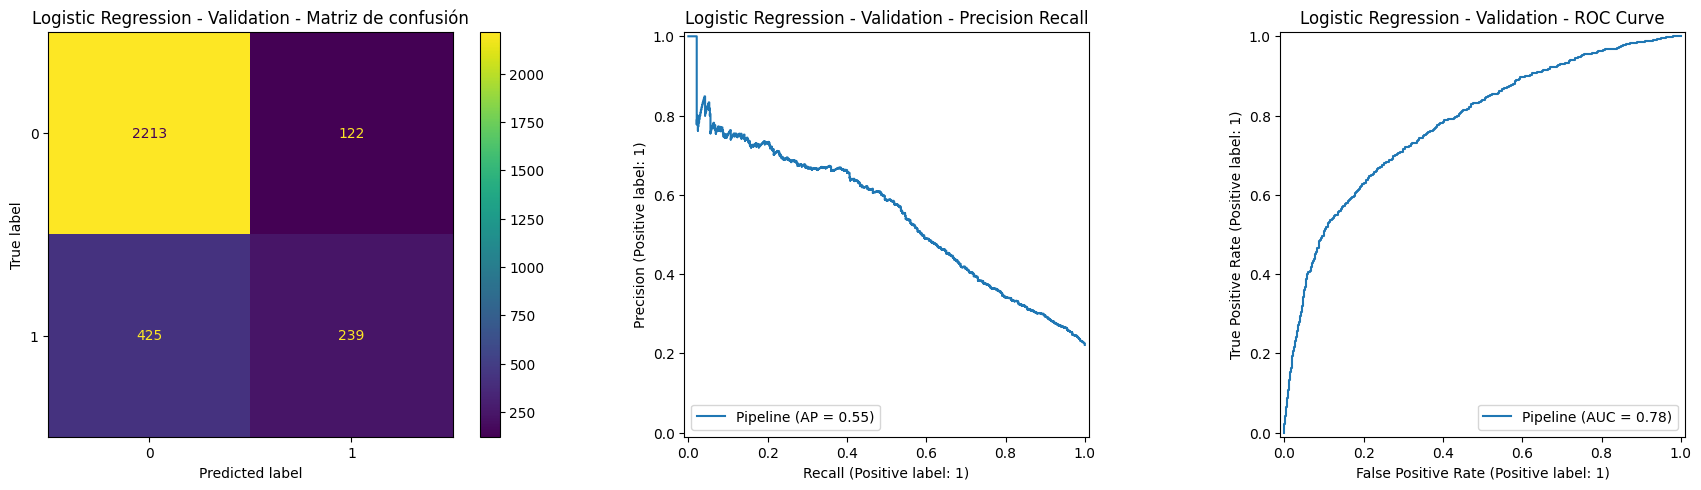

In [39]:
resultados_val = evaluar_clasificador_sklearn(
    model=logistic_pipe,
    X=X_val,
    y_true=y_val,
    clases=[0, 1],
    positive_label=1,
    titulo="Logistic Regression - Validation"
)

In [40]:
def tabla_thresholds(model, X, y_true, thresholds=np.arange(0.10, 0.91, 0.05)):
    y_proba = model.predict_proba(X)[:, 1]

    resultados = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        tn, fp, fn, tp = cm.ravel()

        precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1_1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        resultados.append({
            "threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "precision_default": precision_1,
            "recall_default": recall_1,
            "f1_default": f1_1
        })

    return pd.DataFrame(resultados)

In [41]:
tabla_val_logistic = tabla_thresholds(
    model=logistic_pipe,
    X=X_val,
    y_true=y_val
)

tabla_val_logistic

,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default
0,0.10,561,1774,30,634,0.263289,0.954819,0.412760
1,0.15,1426,909,149,515,0.361657,0.775602,0.493295
2,0.20,1851,484,241,423,0.466373,0.637048,0.538511
3,0.25,1972,363,280,384,0.514056,0.578313,0.544295
4,0.30,2062,273,308,356,0.565978,0.536145,0.550657
5,0.35,2129,206,345,319,0.607619,0.480422,0.536585
6,0.40,2172,163,380,284,0.635347,0.427711,0.511251
7,0.45,2204,131,406,258,0.663239,0.388554,0.490028
8,0.50,2213,122,425,239,0.662050,0.359940,0.466341
9,0.55,2228,107,449,215,0.667702,0.323795,0.436105


## Notas sobre modelo base

El modelo base con threshold de 0.50 deja pasar una cantidad importante de falsos negativos, es decir, clientes que realmente caerían en default pero son clasificados como no default.

Hemos observado que, en este modelo en particular el threshold de .25 es un modelo equilibrado con un f1 score de .549 lo que es mejor que el mero azar para predecir la clase 1 que ayuda a reducir los Falsos Negativos (288 aquellos que valoramos que no harán default pero si lo hacen). Por lo que ese es el punto elegido para el baseline.

(Aquí habria que consultar con negocio hallazgos)

In [42]:
tabla_val_xgb = tabla_thresholds(
    model=xgboost_pipe,
    X=X_val,
    y_true=y_val
)

tabla_val_xgb

,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default
0,0.10,780,1555,51,613,0.282749,0.923193,0.432910
1,0.15,1423,912,156,508,0.357746,0.765060,0.487524
2,0.20,1784,551,225,439,0.443434,0.661145,0.530834
3,0.25,1951,384,262,402,0.511450,0.605422,0.554483
4,0.30,2036,299,291,373,0.555060,0.561747,0.558383
5,0.35,2100,235,325,339,0.590592,0.510542,0.547658
6,0.40,2155,180,362,302,0.626556,0.454819,0.527051
7,0.45,2192,143,398,266,0.650367,0.400602,0.495806
8,0.50,2218,117,418,246,0.677686,0.370482,0.479065
9,0.55,2236,99,444,220,0.689655,0.331325,0.447609


In [43]:
def comparar_utilidad_modelos(
    tablas_modelos,
    ganancia_tn=100,
    costo_fn=500,
    costo_fp=100
):
    resultados = []

    for nombre_modelo, tabla in tablas_modelos.items():
        temp = tabla.copy()

        temp["modelo"] = nombre_modelo

        temp["utilidad"] = (
            temp["TN"] * ganancia_tn
            - temp["FN"] * costo_fn
            - temp["FP"] * costo_fp
        )

        temp["ganancia_tn"] = ganancia_tn
        temp["costo_fn"] = costo_fn
        temp["costo_fp"] = costo_fp

        resultados.append(temp)

    comparacion = pd.concat(resultados, ignore_index=True)

    columnas = [
        "modelo",
        "threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "precision_default",
        "recall_default",
        "f1_default",
        "utilidad"
    ]

    return comparacion[columnas].sort_values(
        "utilidad",
        ascending=False
    )

Para comparar modelos y thresholds se construyó una función de utilidad simplificada basada en la matriz de confusión. Esta función asigna una ganancia a los verdaderos negativos, ya que representan buenos clientes correctamente clasificados, y penaliza falsos positivos y falsos negativos.

En esta primera versión, los verdaderos positivos se dejaron con ganancia cero, ya que detectar correctamente a un cliente en riesgo no genera por sí mismo una ganancia inmediata, sino una oportunidad de mitigación. En un escenario real, este valor podría calibrarse como ahorro esperado si la institución logra reducir la exposición o activar una estrategia preventiva.

In [44]:
comparacion_utilidad = comparar_utilidad_modelos(
    tablas_modelos={
        "Logistic Regression": tabla_val_logistic,
        "XGBoost": tabla_val_xgb
    },
    ganancia_tn=100,
    costo_fn=500,
    costo_fp=100
)

comparacion_utilidad.head(20)

,modelo,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default,utilidad
21,XGBoost,0.30,2036,299,291,373,0.555060,0.561747,0.558383,28200
20,XGBoost,0.25,1951,384,262,402,0.511450,0.605422,0.554483,25700
4,Logistic Regression,0.30,2062,273,308,356,0.565978,0.536145,0.550657,24900
22,XGBoost,0.35,2100,235,325,339,0.590592,0.510542,0.547658,24000
3,Logistic Regression,0.25,1972,363,280,384,0.514056,0.578313,0.544295,20900
5,Logistic Regression,0.35,2129,206,345,319,0.607619,0.480422,0.536585,19800
23,XGBoost,0.40,2155,180,362,302,0.626556,0.454819,0.527051,16500
2,Logistic Regression,0.20,1851,484,241,423,0.466373,0.637048,0.538511,16200
6,Logistic Regression,0.40,2172,163,380,284,0.635347,0.427711,0.511251,10900
19,XGBoost,0.20,1784,551,225,439,0.443434,0.661145,0.530834,10800


Index(['modelo', 'threshold', 'TN', 'FP', 'FN', 'TP', 'precision_default',
       'recall_default', 'f1_default', 'utilidad'],
      dtype='object')


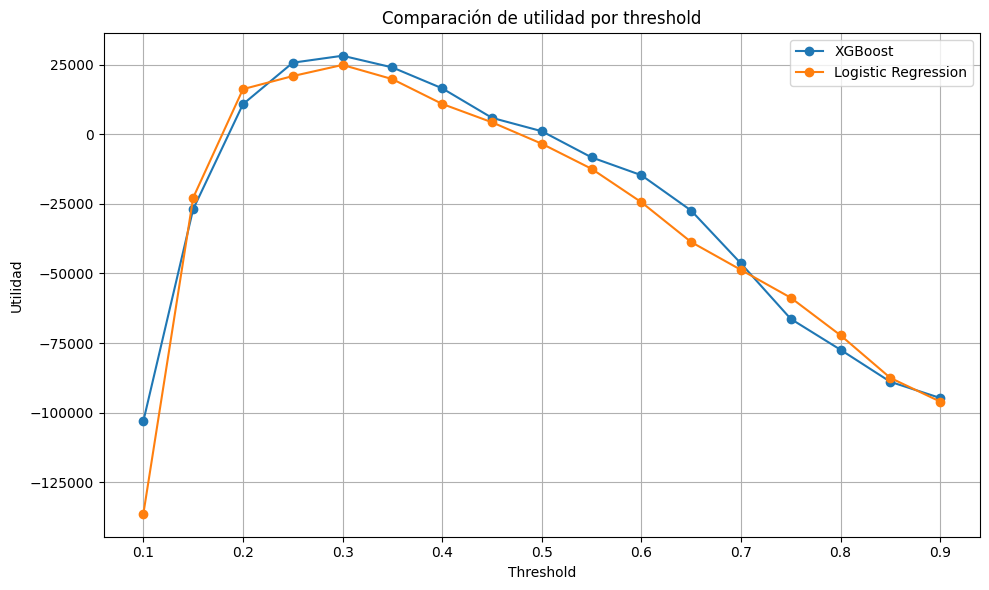

In [45]:
df_plot = comparacion_utilidad.copy()

print(df_plot.columns)

modelo_col = "model" if "model" in df_plot.columns else "modelo"
threshold_col = "threshold" if "threshold" in df_plot.columns else "umbral"
utilidad_col = "utilidad_total" if "utilidad_total" in df_plot.columns else "utilidad"

plt.figure(figsize=(10, 6))

for model_name in df_plot[modelo_col].unique():
    data_plot = (
        df_plot[df_plot[modelo_col] == model_name]
        .sort_values(threshold_col)
    )

    plt.plot(
        data_plot[threshold_col],
        data_plot[utilidad_col],
        marker="o",
        label=model_name
    )

plt.title("Comparación de utilidad por threshold")
plt.xlabel("Threshold")
plt.ylabel("Utilidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Index(['modelo', 'threshold', 'TN', 'FP', 'FN', 'TP', 'precision_default',
       'recall_default', 'f1_default', 'utilidad'],
      dtype='object')


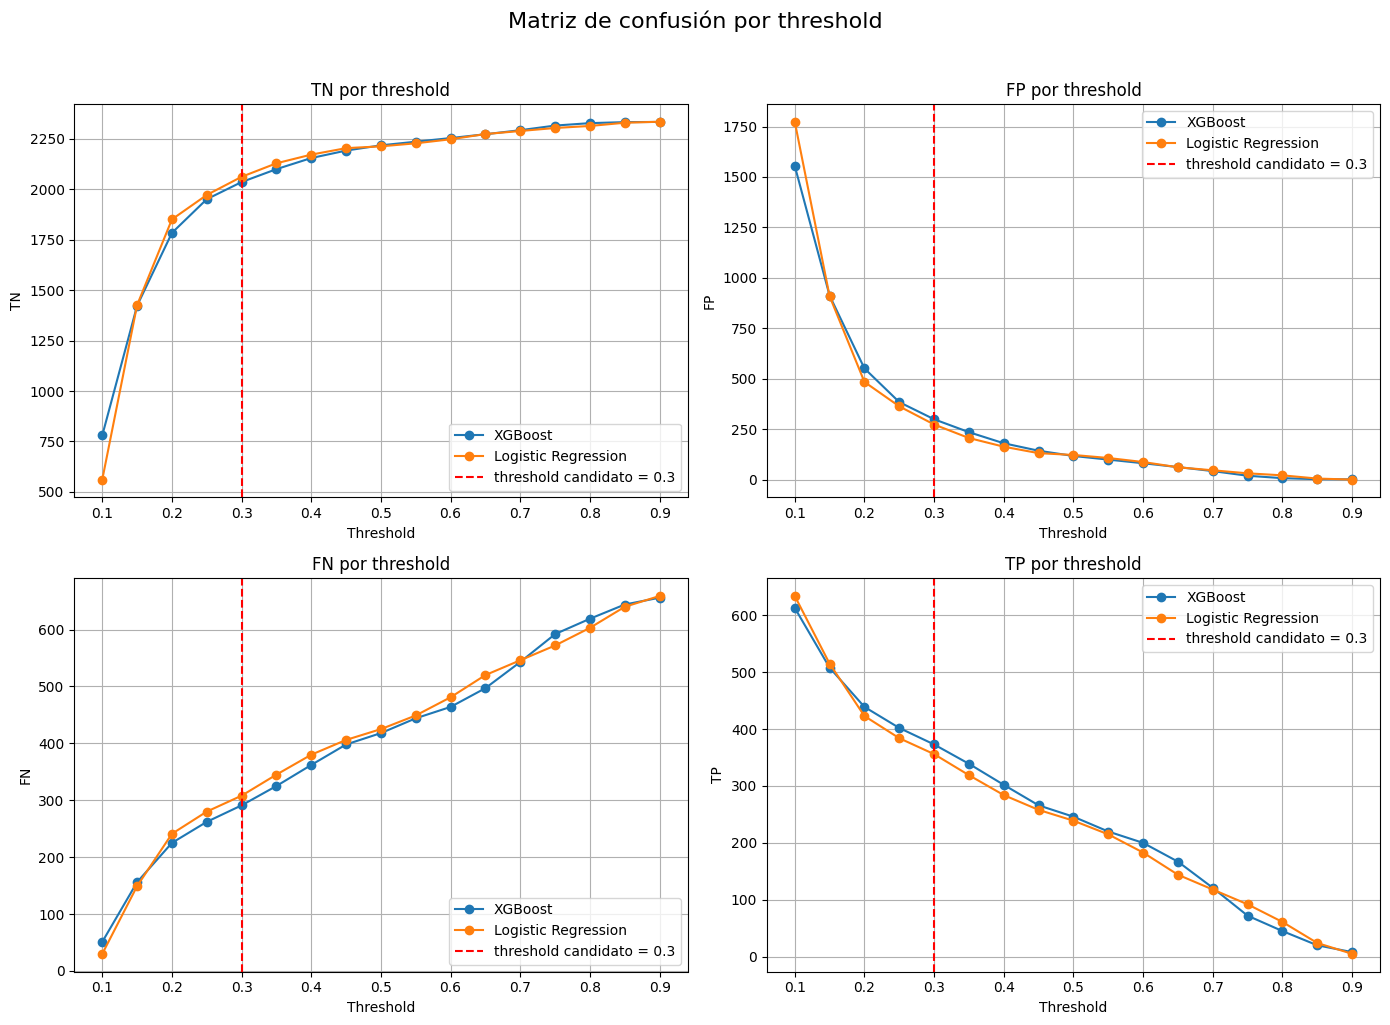

In [46]:
df_plot = comparacion_utilidad.copy()

print(df_plot.columns)

modelo_col = "model" if "model" in df_plot.columns else "modelo"
threshold_col = "threshold" if "threshold" in df_plot.columns else "umbral"

metricas = ["tn", "fp", "fn", "tp"]
threshold_candidato = 0.30

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for ax, metrica in zip(axes, metricas):
    metrica_col = metrica if metrica in df_plot.columns else metrica.upper()

    for model_name in df_plot[modelo_col].unique():
        data_plot = (
            df_plot[df_plot[modelo_col] == model_name]
            .sort_values(threshold_col)
        )

        ax.plot(
            data_plot[threshold_col],
            data_plot[metrica_col],
            marker="o",
            label=model_name
        )

    ax.axvline(
        x=threshold_candidato,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"threshold candidato = {threshold_candidato}"
    )

    ax.set_title(f"{metrica.upper()} por threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel(metrica.upper())
    ax.grid(True)
    ax.legend()

plt.suptitle("Matriz de confusión por threshold", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Conclusiones de Logistic VS XGboost en escenario ficticio

Bajo el escenario definido, un falso positivo representa rechazar a un cliente que habría sido buen pagador; un falso negativo representa aceptar a un cliente que termina haciendo default, con una pérdida estimada de 500; y un verdadero negativo representa aceptar correctamente a un buen pagador, generando una ganancia de 100.

Con esta estructura de costos y beneficios, XGBoost con threshold de 0.30 maximiza la utilidad esperada frente a la regresión logística. Sin embargo, la decisión final del threshold debe validarse con negocio, ya que depende de la tolerancia al riesgo, la rentabilidad real por cliente y el costo económico de cada tipo de error.

In [47]:
from sklearn.model_selection import GridSearchCV

## Logistic Reg

logistic_pipe_tunned = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter = 200))
])

params_grid_logistic = {
    'model__C' : [0.01, 0.1, 10],
    'model__class_weight' : [None, 'balanced'],
    'model__penalty': ['l2'],
    'model__solver' : ['lbfgs', 'newton-cg', 'newton-cholesky']
}

grid_logistic = GridSearchCV(
    logistic_pipe_tunned,
    params_grid_logistic,
    cv = 5,
    scoring = 'recall'
)

grid_logistic.fit(X_train, y_train)

print('Mejores params', grid_logistic.best_params_)
print('Mejor CV Score', grid_logistic.best_score_)

Mejores params {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Mejor CV Score 0.5998457554345029


In [48]:
## Random Forest

preprocessor_forest = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cols_to_one_hot),
        ('num', 'passthrough', numeric_cols)
    ]
)

forest_pipe_tunned = Pipeline([
    ('prep', preprocessor_forest),
    ('model', RandomForestClassifier(random_state = 42))
])

params_grid_forest = {
    'model__n_estimators' : [100],
    'model__criterion' : ['gini', 'log_loss'],

}

grid_forest = GridSearchCV(
    forest_pipe_tunned,
    params_grid_forest,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1,
    verbose = 1
)

grid_forest.fit(X_train, y_train)

print('Mejores params: ', grid_forest.best_params_)
print('Mejore CV Score: ', grid_forest.best_score_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Mejores params:  {'model__criterion': 'gini', 'model__n_estimators': 100}
Mejore CV Score:  0.37132187060141186


In [49]:
## Perceptrón Multicapa

mlp_pipe_tunned = Pipeline([
    ('prep', preprocessor),
    ('model', MLPClassifier(
        max_iter = 300,
        early_stopping = True,
        random_state  = 12
    ))
])

params_grid_mlp = {
    'model__hidden_layer_sizes' : [
        (32,),
        (64,),
    ],
    'model__activation' : ['relu'],
    'model__alpha' : [0.001, 0.01],

}

grid_mlp = GridSearchCV(
    mlp_pipe_tunned,
    params_grid_mlp,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1,
    verbose= 1

)

grid_mlp.fit(X_train, y_train)

print('Mejores params: ', grid_mlp.best_params_)
print('Mejore CV Score: ', grid_mlp.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores params:  {'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (64,)}
Mejore CV Score:  0.3671746620020554


In [50]:
## Arbol de decición

tree_pipe_tunned = Pipeline([
    ('pred', preprocessor),
    ('model', DecisionTreeClassifier(random_state = 42))
])

params_grid_tree = {
    'model__max_depth' : [3, 5, 7],
    'model__min_samples_leaf' : [20, 50],
    'model__class_weight' : [None, 'balanced']
}

grid_tree_dec = GridSearchCV(
    tree_pipe_tunned,
    params_grid_tree,
    cv = 5,
    scoring = 'recall',
    n_jobs = -1,
    verbose = 1

)

grid_tree_dec.fit(X_train, y_train)

print('Mejores params: ', grid_tree_dec.best_params_)
print('Mejore CV Score: ', grid_tree_dec.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores params:  {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 50}
Mejore CV Score:  0.6190746746043156


In [51]:
classification_models = {
    "Logistic Regression Tuned": grid_logistic.best_estimator_,
    "Decision Tree Tuned" : grid_tree_dec.best_estimator_,
    "Random Forest Tuned": grid_forest.best_estimator_,
    "MLP Tuned": grid_mlp.best_estimator_,
    "XGBoost No grid": xgboost_pipe,
}

In [52]:
classification_results = []

for name, model in classification_models.items():
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_val)
    else:
        y_proba = None

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred,
        labels=[0, 1]
    ).ravel()

    classification_results.append({
        "model": name,

        # Métricas generales
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),

        # Métricas con score/probabilidad
        "roc_auc": roc_auc_score(y_val, y_proba) if y_proba is not None else np.nan,
        "pr_auc": average_precision_score(y_val, y_proba) if y_proba is not None else np.nan,

        # Matriz de confusión desglosada
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("pr_auc", ascending=False)
)

classification_results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
4,XGBoost No grid,0.821607,0.677686,0.370482,0.479065,0.785703,0.566904,2218,117,418,246
3,MLP Tuned,0.817939,0.655263,0.375000,0.477011,0.784339,0.560738,2204,131,415,249
0,Logistic Regression Tuned,0.770924,0.486260,0.612952,0.542305,0.779944,0.534485,1905,430,257,407
2,Random Forest Tuned,0.809603,0.618926,0.364458,0.458768,0.765417,0.530405,2186,149,422,242
1,Decision Tree Tuned,0.686229,0.379879,0.659639,0.482113,0.720505,0.457164,1620,715,226,438


## Nota

Es interesante encontrar en el threshold de 50% un FN de 226 dentro del Decision Tree, vale la pena explorarlo.

In [53]:
evaluador = grid_mlp.best_estimator_
nombre_evaluador = 'MLP'

In [54]:
tabla_evaluacion = tabla_thresholds(
    model=evaluador,
    X=X_val,
    y_true=y_val
)

tabla_evaluacion

,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default
0,0.10,797,1538,60,604,0.281979,0.909639,0.430506
1,0.15,1388,947,138,526,0.357094,0.792169,0.492279
2,0.20,1739,596,212,452,0.431298,0.680723,0.528037
3,0.25,1916,419,265,399,0.487775,0.600904,0.538462
4,0.30,2028,307,296,368,0.545185,0.554217,0.549664
5,0.35,2093,242,321,343,0.586325,0.516566,0.549239
6,0.40,2128,207,352,312,0.601156,0.469880,0.527473
7,0.45,2179,156,391,273,0.636364,0.411145,0.499543
8,0.50,2204,131,415,249,0.655263,0.375000,0.477011
9,0.55,2224,111,437,227,0.671598,0.341867,0.453094


In [55]:
comparacion_utilidad = comparar_utilidad_modelos(
    tablas_modelos={
        "XGBoost": tabla_val_xgb,
        nombre_evaluador : tabla_evaluacion
    },
    ganancia_tn=100,
    costo_fn=500,
    costo_fp=100
)

comparacion_utilidad.head(20)

,modelo,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default,utilidad
4,XGBoost,0.30,2036,299,291,373,0.555060,0.561747,0.558383,28200
3,XGBoost,0.25,1951,384,262,402,0.511450,0.605422,0.554483,25700
22,MLP,0.35,2093,242,321,343,0.586325,0.516566,0.549239,24600
21,MLP,0.30,2028,307,296,368,0.545185,0.554217,0.549664,24100
5,XGBoost,0.35,2100,235,325,339,0.590592,0.510542,0.547658,24000
20,MLP,0.25,1916,419,265,399,0.487775,0.600904,0.538462,17200
6,XGBoost,0.40,2155,180,362,302,0.626556,0.454819,0.527051,16500
23,MLP,0.40,2128,207,352,312,0.601156,0.469880,0.527473,16100
2,XGBoost,0.20,1784,551,225,439,0.443434,0.661145,0.530834,10800
19,MLP,0.20,1739,596,212,452,0.431298,0.680723,0.528037,8300


In [56]:
from sklearn.model_selection import RandomizedSearchCV


xgboost_pipe_tunned = Pipeline([
    ('prep', preprocessor_xgb),
    ('model', xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

params_random_xgboost = {
    'model__n_estimators': [200, 250, 300, 350, 400, 450],
    'model__learning_rate': [0.025, 0.03, 0.04, 0.05, 0.06, 0.075, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__tree_method': ['hist'],
    'model__min_child_weight': [1, 2, 3, 5],
    'model__gamma': [0, 0.1, 0.25, 0.5, 1],
    'model__subsample': [0.75, 0.85, 0.95, 1.0],
    'model__colsample_bytree': [0.75, 0.85, 0.95, 1.0],
    'model__reg_alpha': [0, 0.01, 0.05, 0.1, 0.5],
    'model__reg_lambda': [0.5, 1, 2, 3, 5]
}

random_xgboost = RandomizedSearchCV(
    estimator=xgboost_pipe_tunned,
    param_distributions=params_random_xgboost,
    n_iter=60,
    cv=3,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_xgboost.fit(X_train, y_train)

print('Mejores params:', random_xgboost.best_params_)
print('Mejor CV Score:', random_xgboost.best_score_)
best_xgboost = random_xgboost.best_estimator_


Fitting 3 folds for each of 60 candidates, totalling 180 fits
Mejores params: {'model__tree_method': 'hist', 'model__subsample': 0.85, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0.5, 'model__colsample_bytree': 1.0}
Mejor CV Score: 0.373773046791414


In [57]:
from sklearn.metrics import make_scorer, fbeta_score

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

random_xgboost = RandomizedSearchCV(
    estimator=xgboost_pipe_tunned,
    param_distributions=params_random_xgboost,
    n_iter=60,
    cv=3,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_xgboost.fit(X_train, y_train)

print('Mejores params:', random_xgboost.best_params_)
print('Mejor CV F2:', random_xgboost.best_score_)
best_xgboost = random_xgboost.best_estimator_

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Mejores params: {'model__tree_method': 'hist', 'model__subsample': 0.85, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__gamma': 0.5, 'model__colsample_bytree': 1.0}
Mejor CV F2: 0.4091749679703632


La búsqueda de hiperparámetros se orientó inicialmente a mejorar recall, dado que el falso negativo es especialmente costoso en un problema de default. Posteriormente, los modelos candidatos se compararon con una función de utilidad ficticia para equilibrar el costo de falsos negativos y falsos positivos.

In [58]:
tabla_evaluacion = tabla_thresholds(
    model=best_xgboost,
    X=X_val,
    y_true=y_val
)

tabla_evaluacion

,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default
0,0.10,910,1425,75,589,0.292453,0.887048,0.439881
1,0.15,1430,905,160,504,0.357700,0.759036,0.486252
2,0.20,1734,601,213,451,0.428707,0.679217,0.525641
3,0.25,1913,422,256,408,0.491566,0.614458,0.546185
4,0.30,2019,316,299,365,0.535977,0.549699,0.542751
5,0.35,2094,241,324,340,0.585198,0.512048,0.546185
6,0.40,2146,189,360,304,0.616633,0.457831,0.525497
7,0.45,2190,145,383,281,0.659624,0.423193,0.515596
8,0.50,2218,117,415,249,0.680328,0.375000,0.483495
9,0.55,2235,100,439,225,0.692308,0.338855,0.455005


In [59]:
nombre_evaluador = 'XGBoostRand'

In [60]:
comparacion_utilidad = comparar_utilidad_modelos(
    tablas_modelos={
        "XGBoost": tabla_val_xgb,
        nombre_evaluador : tabla_evaluacion
    },
    ganancia_tn=100,
    costo_fn=500,
    costo_fp=100
)

comparacion_utilidad.head(20)

,modelo,threshold,TN,FP,FN,TP,precision_default,recall_default,f1_default,utilidad
4,XGBoost,0.30,2036,299,291,373,0.555060,0.561747,0.558383,28200
3,XGBoost,0.25,1951,384,262,402,0.511450,0.605422,0.554483,25700
5,XGBoost,0.35,2100,235,325,339,0.590592,0.510542,0.547658,24000
22,XGBoostRand,0.35,2094,241,324,340,0.585198,0.512048,0.546185,23300
20,XGBoostRand,0.25,1913,422,256,408,0.491566,0.614458,0.546185,21100
21,XGBoostRand,0.30,2019,316,299,365,0.535977,0.549699,0.542751,20800
6,XGBoost,0.40,2155,180,362,302,0.626556,0.454819,0.527051,16500
23,XGBoostRand,0.40,2146,189,360,304,0.616633,0.457831,0.525497,15700
24,XGBoostRand,0.45,2190,145,383,281,0.659624,0.423193,0.515596,13000
2,XGBoost,0.20,1784,551,225,439,0.443434,0.661145,0.530834,10800


Index(['modelo', 'threshold', 'TN', 'FP', 'FN', 'TP', 'precision_default',
       'recall_default', 'f1_default', 'utilidad'],
      dtype='object')


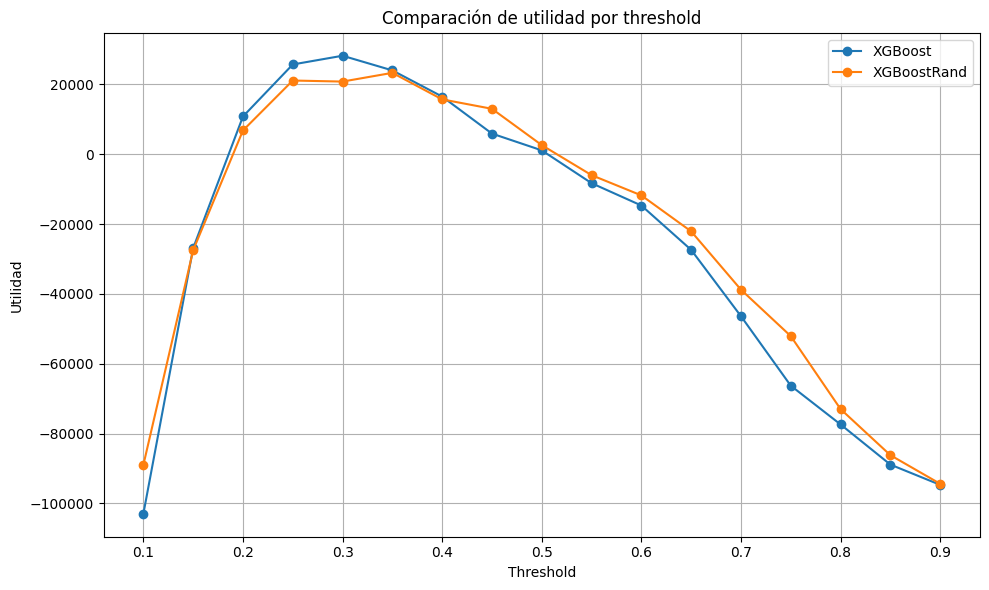

In [61]:
df_plot = comparacion_utilidad.copy()

print(df_plot.columns)

modelo_col = "model" if "model" in df_plot.columns else "modelo"
threshold_col = "threshold" if "threshold" in df_plot.columns else "umbral"
utilidad_col = "utilidad_total" if "utilidad_total" in df_plot.columns else "utilidad"

plt.figure(figsize=(10, 6))

for model_name in df_plot[modelo_col].unique():
    data_plot = (
        df_plot[df_plot[modelo_col] == model_name]
        .sort_values(threshold_col)
    )

    plt.plot(
        data_plot[threshold_col],
        data_plot[utilidad_col],
        marker="o",
        label=model_name
    )

plt.title("Comparación de utilidad por threshold")
plt.xlabel("Threshold")
plt.ylabel("Utilidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusión sobre XGBoost

Aunque el XGBoost ajustado por RandomizedSearch tuvo un desempeño comparable, no superó al modelo base bajo la función de utilidad definida. Por ello se conservó el XGBoost original con threshold de 0.30.

In [62]:
final_model = xgboost_pipe
final_threshold = 0.30

# Predicción sobre TEST
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_test,
    labels=[0, 1]
).ravel()

final_classification_test_sum = pd.DataFrame([{
    "model": "XGBoost",
    "threshold": final_threshold,
    "dataset": "test",
    "accuracy": accuracy_score(y_test, y_pred_test),
    "precision_default": precision_score(y_test, y_pred_test, zero_division=0),
    "recall_default": recall_score(y_test, y_pred_test, zero_division=0),
    "f1_default": f1_score(y_test, y_pred_test, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_test),
    "pr_auc": average_precision_score(y_test, y_proba_test),
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}])

final_classification_test_sum

,model,threshold,dataset,accuracy,precision_default,recall_default,f1_default,roc_auc,pr_auc,tn,fp,fn,tp
0,XGBoost,0.3,test,0.797599,0.543645,0.534639,0.539104,0.789564,0.563046,2037,298,309,355


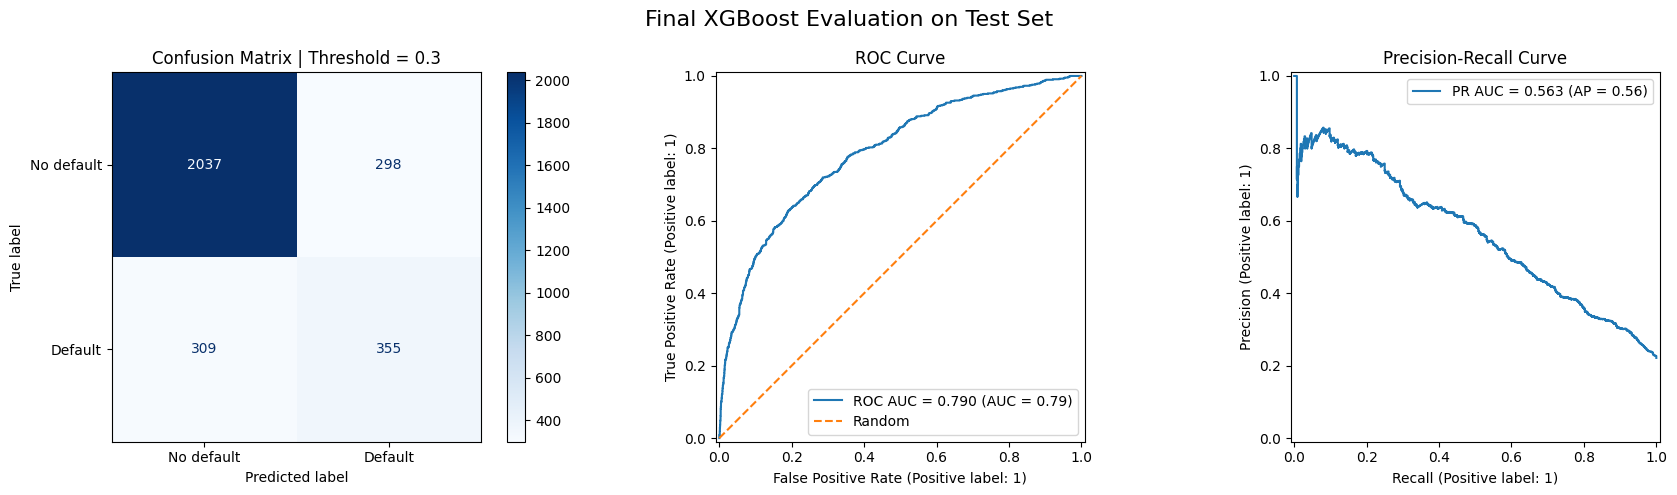

In [63]:
roc_auc = roc_auc_score(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    labels=[0, 1],
    display_labels=["No default", "Default"],
    cmap="Blues",
    values_format="d",
    ax=axes[0]
)

axes[0].set_title(f"Confusion Matrix | Threshold = {final_threshold}")

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_test,
    name=f"ROC AUC = {roc_auc:.3f}",
    ax=axes[1]
)

axes[1].plot([0, 1], [0, 1], linestyle="--", label="Random")
axes[1].set_title("ROC Curve")
axes[1].legend()

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_test,
    name=f"PR AUC = {pr_auc:.3f}",
    ax=axes[2]
)

axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

fig.suptitle("Final XGBoost Evaluation on Test Set", fontsize=16)

plt.tight_layout()
plt.show()

## Selección del modelo de clasificación

El objetivo de clasificación consiste en predecir si un cliente caerá en default el siguiente mes. Debido al desbalance de clases y al contexto de riesgo crediticio, la evaluación no se basó únicamente en accuracy.

Se entrenaron modelos lineales, árboles de decisión, ensambles, boosting y una red neuronal simple. Primero se compararon los modelos en el conjunto de validación usando métricas estándar: accuracy, precision, recall, F1, ROC AUC y PR AUC.

Posteriormente se evaluaron distintos thresholds de decisión, ya que en este problema el costo de un falso negativo puede ser mayor que el costo de un falso positivo. Para aproximar esta lógica de negocio, se construyó una función de utilidad ficticia que penaliza falsos negativos y falsos positivos de forma diferenciada.

Bajo este criterio, el modelo seleccionado fue XGBoost con threshold de 0.30, ya que mostró el mejor balance entre detección de defaults y costo operativo esperado en validación.

## Modelo de regression

In [64]:
target_reg = "PAY_AMT4"

features_reg = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df_features_reg = data[features_reg].copy()

In [65]:
skew_view = df_features_reg.skew().reset_index()

skew_view.columns = ['variable', 'skewness']

skew_view = skew_view.sort_values('skewness', ascending = False)
skew_view

,variable,skewness
11,PAY_AMT4,12.904985
12,PAY_AMT5,11.127417
13,PAY_AMT6,10.640727
9,BILL_AMT5,2.876380
10,BILL_AMT6,2.846645
8,BILL_AMT4,2.821965
6,PAY_5,1.008197
5,PAY_4,0.999629
0,LIMIT_BAL,0.992867
2,EDUCATION,0.970972


In [66]:
log_cols = skew_view[skew_view['skewness'] >= 3]['variable'].to_list()
log_cols

['PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [67]:
feature_cols = df_features_reg.copy()
feature_cols.pop(target_reg)

X = feature_cols.copy()
X_const =add_constant(X)

vif_data = pd.DataFrame()
vif_data['variable'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data = (
    vif_data[vif_data['variable'] != 'const']
    .sort_values('VIF', ascending = False)
)

vif_data

,variable,VIF
10,BILL_AMT5,19.680403
11,BILL_AMT6,14.578883
9,BILL_AMT4,8.944228
7,PAY_5,4.604425
8,PAY_6,3.197042
6,PAY_4,3.173969
12,PAY_AMT5,1.585453
1,LIMIT_BAL,1.465657
5,AGE,1.274472
4,MARRIAGE,1.228993


In [68]:
## Otro run de VIF sin las variables con multico
high_vif_cols = vif_data[vif_data['VIF']> 10]['variable'].to_list()
all_vars = vif_data['variable'].to_list()

for exclude in high_vif_cols:
  all_vars.remove(exclude)

df_features_reg_vif1 = df_features_reg[all_vars]

X = df_features_reg_vif1.copy()
X_const =add_constant(X)

vif_data = pd.DataFrame()
vif_data['variable'] = X_const.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data_ver_2 = (
    vif_data[vif_data['variable'] != 'const']
    .sort_values('VIF', ascending = False)
)

vif_data_ver_2

,variable,VIF
2,PAY_5,4.584144
4,PAY_4,3.172871
3,PAY_6,3.107736
6,LIMIT_BAL,1.452480
1,BILL_AMT4,1.329323
7,AGE,1.274447
8,MARRIAGE,1.228935
10,EDUCATION,1.120056
9,PAY_AMT6,1.078005
5,PAY_AMT5,1.073882


In [69]:
## Reconstruimos la lista completa con el target
feature_cols_reg = vif_data_ver_2['variable'].to_list()
importer = feature_cols_reg
importer.append(target_reg)

In [70]:
importer

['PAY_5',
 'PAY_4',
 'PAY_6',
 'LIMIT_BAL',
 'BILL_AMT4',
 'AGE',
 'MARRIAGE',
 'EDUCATION',
 'PAY_AMT6',
 'PAY_AMT5',
 'SEX',
 'PAY_AMT4']

In [71]:
log_cols

['PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [72]:
final_frame_reg = data[importer].copy()

X = final_frame_reg.copy()
y = X.pop(target_reg)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   PAY_5      30000 non-null  int64
 1   PAY_4      30000 non-null  int64
 2   PAY_6      30000 non-null  int64
 3   LIMIT_BAL  30000 non-null  int64
 4   BILL_AMT4  30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   MARRIAGE   30000 non-null  int64
 7   EDUCATION  30000 non-null  int64
 8   PAY_AMT6   30000 non-null  int64
 9   PAY_AMT5   30000 non-null  int64
 10  SEX        30000 non-null  int64
dtypes: int64(11)
memory usage: 2.5 MB


In [74]:
feature_cols_reg_copy = X.columns
feature_cols_reg_copy

Index(['PAY_5', 'PAY_4', 'PAY_6', 'LIMIT_BAL', 'BILL_AMT4', 'AGE', 'MARRIAGE',
       'EDUCATION', 'PAY_AMT6', 'PAY_AMT5', 'SEX'],
      dtype='object')

In [75]:
feature_cols_reg_copy = X.columns

cat_features_reg = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numeric_features_reg = [nombre for nombre in feature_cols_reg_copy
                        if nombre not in cat_features_reg
                        and nombre not in log_cols
]

log_cols_features_reg = [
    col for col in log_cols
    if col != target
]

log_cols_features_reg.remove(target_reg)

In [76]:
print("Cat:", cat_features_reg)
print("Num:", numeric_features_reg)
print("Log:", log_cols_features_reg)

Cat: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_4', 'PAY_5', 'PAY_6']
Num: ['LIMIT_BAL', 'BILL_AMT4', 'AGE']
Log: ['PAY_AMT5', 'PAY_AMT6']


In [77]:
from sklearn.compose import TransformedTargetRegressor

log_transformer_reg = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out = 'one-to-one')),
    ('scaler', StandardScaler())
])

numeric_transformer_reg = Pipeline([
    ('scaler', StandardScaler())
])

cat_transformer_reg = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor_reg = ColumnTransformer(
    transformers = [
        ('log_num', log_transformer_reg, log_cols_features_reg),
        ('num', numeric_transformer_reg, numeric_features_reg),
        ('cat', cat_transformer_reg, cat_features_reg)
    ],
    remainder = 'drop'
)

base_reg_pipe = Pipeline([
    ('prep', preprocessor_reg),
    ('model', LinearRegression())
])

reg_pipe = TransformedTargetRegressor(
    regressor = base_reg_pipe,
    func = np.log1p,
    inverse_func = np.expm1
)


reg_pipe.fit(X_train_reg, y_train_reg)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('log_num',
                                                                                       Pipeline(steps=[('log1p',
                                                                                                        FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                            func=<ufunc 'log1p'>)),
                                                                                                       ('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['PAY_AMT5',
                                                                                        'PAY_AMT6']),
                                                                                      ('num',
                                                                                       Pipeline(steps=[('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['LIMIT_BAL',
                                                                                        'BILL_AMT4',
                                                                                        'AGE']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('onehot',
                                                                                                        OneHotEncoder(handle_unknown='ignore'))]),
                                                                                       ['SEX',
                                                                                        'EDUCATION',
                                                                                        'MARRIAGE',
                                                                                        'PAY_4',
                                                                                        'PAY_5',
                                                                                        'PAY_6'])])),
                                                     ('model',
                                                      LinearRegression())]))

In [78]:
y_pred_reg = reg_pipe.predict(X_test_reg)

y_pred_reg = np.maximum(y_pred_reg, 0)

reg_results_original = {
    "MAE": mean_absolute_error(y_test_reg, y_pred_reg),
    "MedianAE": median_absolute_error(y_test_reg, y_pred_reg),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
    "R2": r2_score(y_test_reg, y_pred_reg)
}

reg_results_original

{'MAE': 4436.016837078227,
 'MedianAE': np.float64(586.6198726724482),
 'RMSE': np.float64(25670.24025995662),
 'R2': -3.0251546663164923}

In [79]:
log_metrics = {
    "MAE_log": mean_absolute_error(np.log1p(y_test_reg), np.log1p(y_pred_reg)),
    "RMSE_log": np.sqrt(mean_squared_error(np.log1p(y_test_reg), np.log1p(y_pred_reg))),
    "R2_log": r2_score(np.log1p(y_test_reg), np.log1p(y_pred_reg))
}

log_metrics

{'MAE_log': 1.493506379699887,
 'RMSE_log': np.float64(2.1981269235958205),
 'R2_log': 0.5747834531460176}

El modelo de regresión no se considera listo para uso productivo en escala monetaria original, dado que obtuvo un R² negativo. Sin embargo, el desempeño en escala logarítmica sugiere que el modelo captura parte del orden de magnitud del pago. Por ello, se interpreta como un ejercicio exploratorio y no como un estimador final de monto.

### Resultados del modelo de regresión

Para la tarea de regresión se intentó predecir el monto de pago `PAY_AMT4`. Esta variable presenta una distribución altamente asimétrica: aproximadamente 21% de los registros tienen valor cero, la mediana es considerablemente menor que la media y existen valores extremos muy alejados del comportamiento típico.

Debido a esta distribución, se aplicó una transformación `log1p` al target mediante `TransformedTargetRegressor`, con el objetivo de reducir el efecto de la cola derecha y permitir que el modelo aprendiera mejor el orden de magnitud del pago.

En escala original, las métricas como RMSE y R2 fueron afectadas por los valores extremos. Sin embargo, en escala logarítmica el modelo obtuvo un `R2_log` de 0.57, lo cual indica que sí captura una proporción razonable de la variabilidad relativa del monto de pago.

Aun así, desde una perspectiva de negocio, la predicción exacta del monto pagado es menos estable que la clasificación de default. Por esta razón, el modelo de regresión se interpreta como un ejercicio exploratorio complementario, mientras que el análisis principal se concentra en los modelos de clasificación, que resultan más accionables para estimar riesgo crediticio.

### Futuros pasos

Como mejora futura, el problema de regresión podría reformularse de distintas maneras:

1. Entrenar un modelo en dos etapas: primero clasificar si el cliente realizará algún pago y después estimar el monto únicamente para quienes sí pagan.
2. Convertir el monto de pago en rangos o bandas, transformando el problema en una tarea de clasificación ordinal.
3. Probar modelos no lineales y robustos frente a outliers, como Random Forest, Gradient Boosting o XGBoost Regressor.
4. Aplicar técnicas de winsorización o tratamiento específico de valores extremos para reducir el impacto de pagos atípicamente altos.
5. Incorporar variables adicionales relacionadas con ingresos, historial financiero o comportamiento reciente del cliente, si estuvieran disponibles.

Estas alternativas podrían mejorar la estabilidad del modelo, especialmente considerando que `PAY_AMT4` combina muchos valores cero, alta dispersión y una cola derecha muy pronunciada.